Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/synthetic_qr_transaction_data.csv")
df.head()



,amount,hour,merchant_new,txn_count_today,anomaly_flag
0,21000,4,0,5,0
1,25613,16,0,6,1
2,39699,7,0,3,1
3,36454,14,0,2,1
4,33041,19,0,3,1


Dataset Structure & Size

In [5]:
df.shape
df.columns


Index(['amount', 'hour', 'merchant_new', 'txn_count_today', 'anomaly_flag'], dtype='object')

Data Types & Missing Values

In [6]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   amount           3000 non-null   int64
 1   hour             3000 non-null   int64
 2   merchant_new     3000 non-null   int64
 3   txn_count_today  3000 non-null   int64
 4   anomaly_flag     3000 non-null   int64
dtypes: int64(5)
memory usage: 117.3 KB


amount             0
hour               0
merchant_new       0
txn_count_today    0
anomaly_flag       0
dtype: int64

Summary Statistics

In [7]:
df.describe()


,amount,hour,merchant_new,txn_count_today,anomaly_flag
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,24863.794667,11.633667,0.306333,3.994000,0.607333
std,14490.581461,6.890716,0.461047,2.007313,0.488425
min,52.000000,0.000000,0.000000,1.000000,0.000000
25%,12313.250000,6.000000,0.000000,2.000000,0.000000
50%,24581.000000,12.000000,0.000000,4.000000,1.000000
75%,37431.500000,18.000000,1.000000,6.000000,1.000000
max,49991.000000,23.000000,1.000000,7.000000,1.000000


UNIVARIATE ANALYSIS

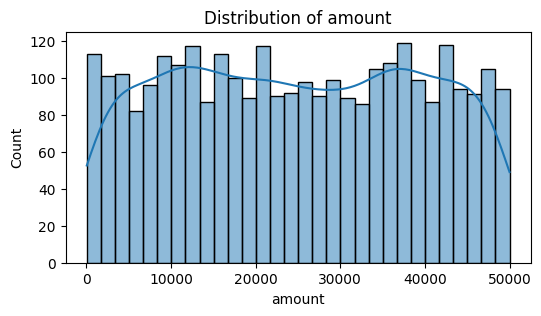

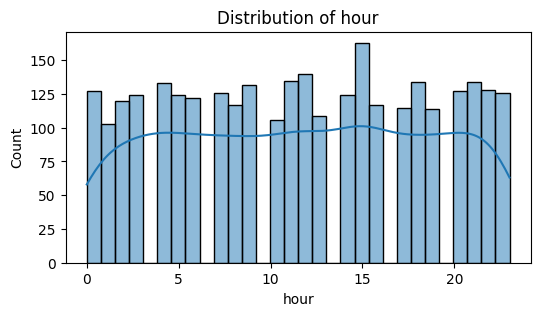

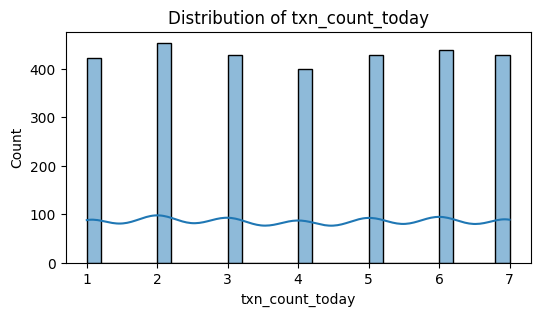

In [9]:
qr_cols = ['amount', 'hour', 'txn_count_today']

for col in qr_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(qr_df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


BIVARIATE ANALYSIS

Amount vs Anomaly

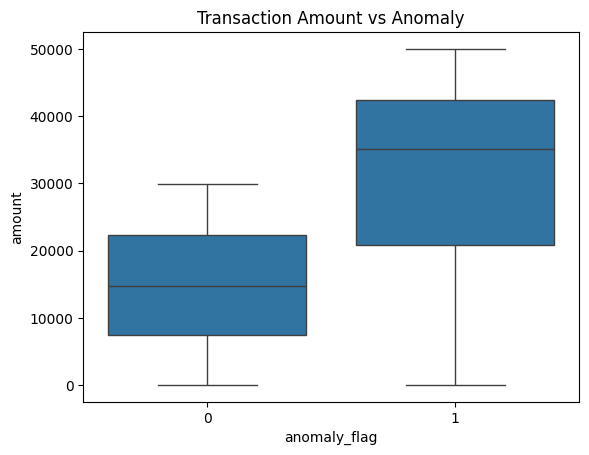

In [10]:
sns.boxplot(x='anomaly_flag', y='amount', data=qr_df)
plt.title("Transaction Amount vs Anomaly")
plt.show()


Merchant Type vs Anomaly

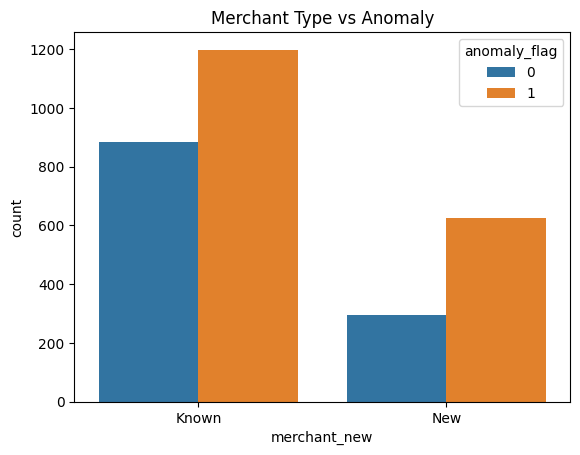

In [11]:
sns.countplot(x='merchant_new', hue='anomaly_flag', data=qr_df)
plt.xticks([0,1], ['Known', 'New'])
plt.title("Merchant Type vs Anomaly")
plt.show()


CORRELATION ANALYSIS

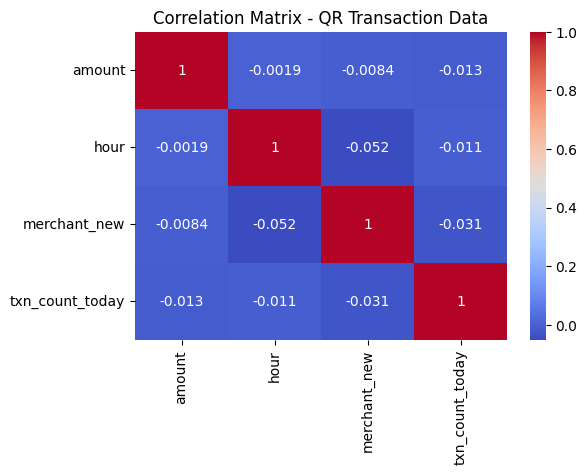

In [12]:
qr_corr = qr_df[['amount','hour','merchant_new','txn_count_today']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(qr_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix - QR Transaction Data")
plt.show()


OUTLIER DETECTION

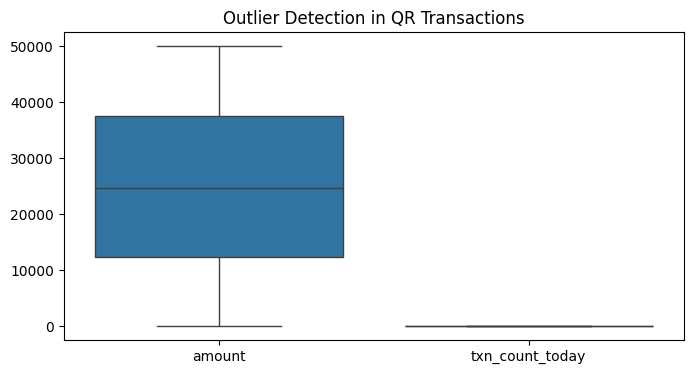

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(data=qr_df[['amount','txn_count_today']])
plt.title("Outlier Detection in QR Transactions")
plt.show()
